## Bmw Sales & Revenue Analysis (2018-2025)

## Import Libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
bmw_dataset=pd.read_csv("bmw_global_sales_2018_2025.csv")
bmw_dataset

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41


## Objective

To analyze BMW sales data and generate meaningful insights on trends, regional performance, 
and revenue to support data-driven decision-making and showcase real-world data analysis skills.

## Dataset Overview

This dataset contains BMW sales data with details on year, month, region, model, units sold, and revenue.
It is used to analyze sales trends and business performance.

## Data Cleaning

The dataset was sourced from Kaggle and was already well-structured. It was checked for missing values and duplicate records to ensure data quality.
No significant issues were found, and the dataset was ready for analysis.

In [3]:
bmw_dataset.info()
bmw_dataset.isnull().sum()
bmw_dataset.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


np.int64(0)

## Analysis Section

### Sales Trend (year)

In [4]:
# Step 1: Data preparation
sales_trend=bmw_dataset.groupby(by="Year")["Units_Sold"].sum()
sales_trend



Year
2018    2765193
2019    2759838
2020    3036556
2021    3036564
2022    3083306
2023    3177788
2024    3293423
2025    3362777
Name: Units_Sold, dtype: int64

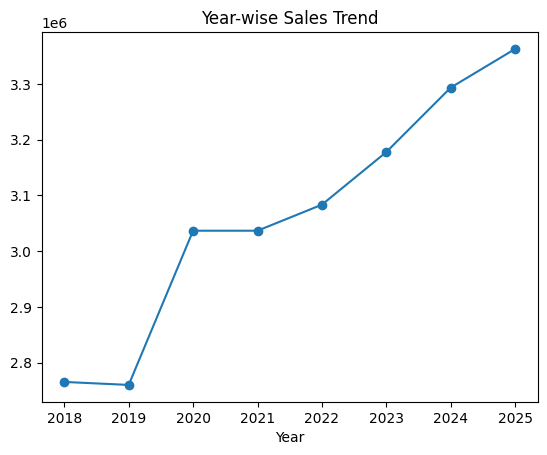

In [5]:
# Step 2: Data Visualization
sales_trend.plot(marker="o")
plt.title("Year-wise Sales Trend")
plt.show()

**Insight:**

Sales experienced a slight decline initially, followed by a strong recovery and consistent growth in subsequent years.

### Seasonality (Month)

In [6]:
# Step 1: Data Preparation
seasonbality_sold=bmw_dataset.groupby(by=["Year","Month"])["Units_Sold"].sum().reset_index()
seasonbality_sold

,Year,Month,Units_Sold
0,2018,1,230195
1,2018,2,201033
2,2018,3,250912
3,2018,4,249552
4,2018,5,218362
...,...,...,...
91,2025,8,260474
92,2025,9,306776
93,2025,10,237864
94,2025,11,285728


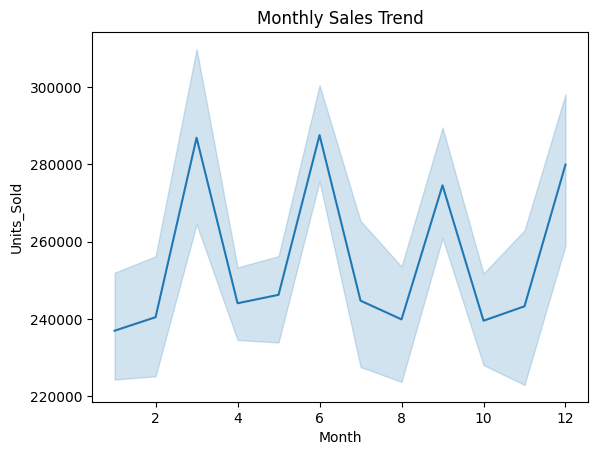

In [7]:
# Step 2: Data Visualization
sns.lineplot(data=seasonbality_sold,x="Month",y="Units_Sold",markers="o")
plt.title("Monthly Sales Trend")
plt.show()

**Insight:**

Sales fluctuate across months. From month 1 to 2, sales increase from 230000 to 240000 units. 
Then sales drop from month 2 to 3 and 3 to 4, before increasing again around month 5 and reaching about 280000 units.
After that, sales decline in months 6 to 7, remain slightly lower in month 8, and then increase again in months 9 and 12, 
reaching above 270000 units. Overall, the sales show an up-and-down seasonal pattern throughout the year.

### Region Analysis

In [8]:
# Step 1: Data Preparation
region_sales=bmw_dataset.groupby(by="Region")["Units_Sold"].sum()
region_sales


Region
China          6256750
Europe         6045176
RestOfWorld    6113872
USA            6099647
Name: Units_Sold, dtype: int64

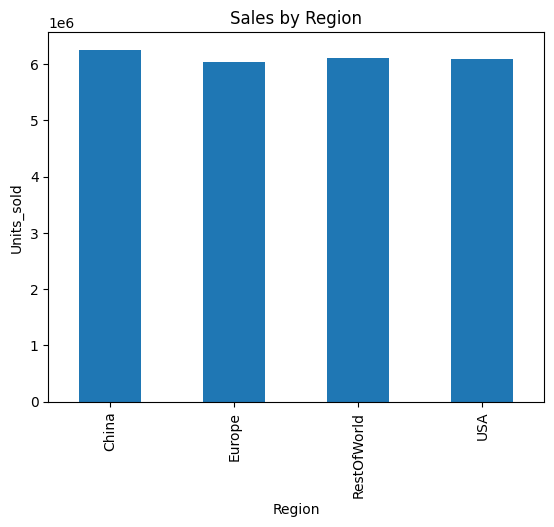

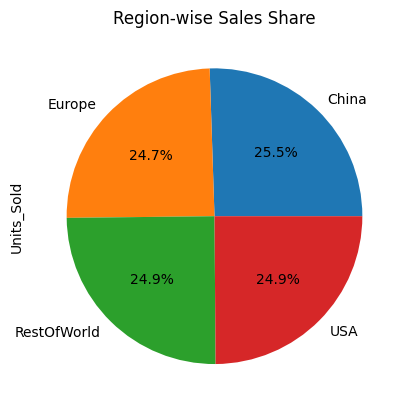

In [9]:
# Step 2: Data Visualization
# step 2.2: Bar chart
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Units_sold")
plt.show()
  
# step 2.2: pie chart
region_sales.plot(kind="pie",autopct="%1.1f%%")
plt.title("Region-wise Sales Share")

plt.show()

**Insight:Bar chart**

All four regions—China, Europe, Rest of the World, and USA—show almost similar sales values, 
with no major variation. Each region contributes around or slightly above 6 units, indicating 
a balanced distribution of sales across regions.

**Insight:Pie Chart**

Sales distribution is evenly spread across regions. China accounts for 25.5%, Europe 24.7%, 
and both Rest of the World and USA contribute 24.9% each, showing nearly equal market share among all regions.




### Model Performance (KPI)

In [10]:
# Step 1: Data Preparation
model_kpi=bmw_dataset.groupby(by="Model").agg({"Units_Sold":"sum","Revenue_EUR":"sum","Avg_Price_EUR":"mean"})
model_kpi["Units_Rank"]=model_kpi["Units_Sold"].rank(ascending=False)
model_kpi["Revenue_Rank"]=model_kpi["Revenue_EUR"].rank(ascending=False)
model_kpi
model_kpi.sort_values("Revenue_EUR",ascending=False)


,Units_Sold,Revenue_EUR,Avg_Price_EUR,Units_Rank,Revenue_Rank
Model,,,,,
X7,3112074,286427856714,92006.489583,3.0,1.0
iX,3136912,235060013889,74965.343750,1.0,2.0
X5,3085134,212814244305,68940.979167,4.0,3.0
i4,3125687,202904898753,64919.351562,2.0,4.0
5 Series,3052524,188992092821,61935.234375,5.0,5.0
X3,3025861,175547140738,58018.552083,6.0,6.0
3 Series,3006048,144338948833,47986.494792,7.0,7.0
MINI,2971205,124934102065,42064.046875,8.0,8.0


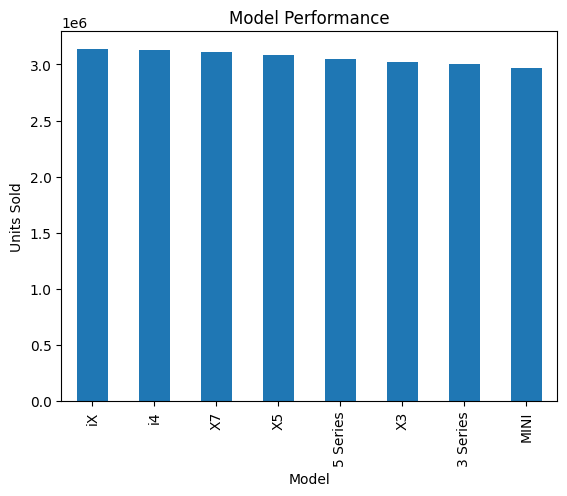

In [11]:
# Step 2: Data Visualization
model_kpi["Units_Sold"].sort_values(ascending=False).plot(kind="bar")
plt.title("Model Performance")
plt.ylabel("Units Sold")
plt.show()

**Insight:**

All models show consistent performance within a narrow range, indicating stable demand and a well-balanced product portfolio.

### Region vs Model

In [12]:
# Step 1: Data preparation
region_model=bmw_dataset.groupby(by=["Region","Model"])["Units_Sold"].sum().sort_values(ascending=False).reset_index()
region_model
pivot_table=region_model.pivot(index="Region",columns="Model",values="Units_Sold")
pivot_table


Model,3 Series,5 Series,MINI,X3,X5,X7,i4,iX
Region,,,,,,,,
China,711402,813129,735790,794213,816868,763185,765519,856644
Europe,733992,742724,735605,709038,744099,820143,800865,758710
RestOfWorld,768488,746266,762095,763639,745215,784423,779974,763772
USA,792166,750405,737715,758971,778952,744323,779329,757786


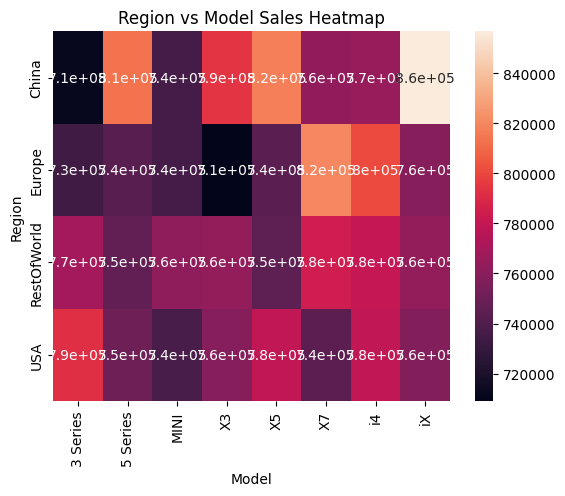

In [13]:
# Step 2: Data visualization
sns.heatmap(data=pivot_table,annot=True)
plt.title("Region vs Model Sales Heatmap")
plt.show()


**Insight:**

The heatmap shows that X5 and X7 models perform strongly across almost all regions. In China, X7 and iX have the highest sales. In the USA market, 3 Series and X5 show strong performance. Europe displays uneven demand, where X7 performs well but X3 has relatively lower sales. In the Rest of the World, most models have similar performance levels. Overall, Mini and X3 appear to be weaker performers in some regions.

### Units vs Revenue

In [14]:
# Step 1: Data Preparation
comparison_month=bmw_dataset.groupby(by="Month")[["Units_Sold","Revenue_EUR"]].sum()
comparison_month



,Units_Sold,Revenue_EUR
Month,,
1,1895883,122516316604
2,1923832,123613516240
3,2295284,147042930300
4,1952674,125427865933
5,1970167,125351595021
6,2300799,147821566931
7,1958031,124390475183
8,1919289,123231274485
9,2196858,140833259577


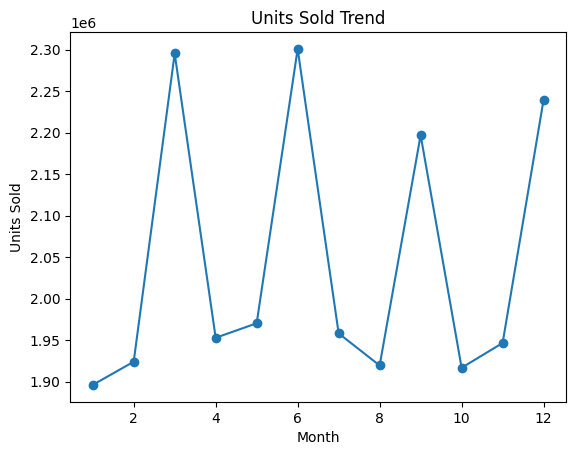

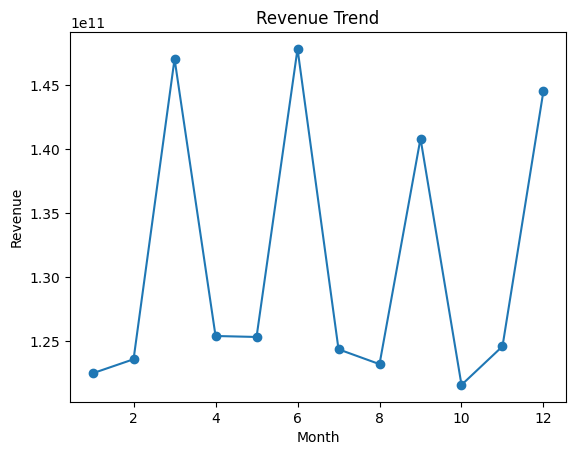

In [15]:
# Step 2: Data Visualization 
# step 2.1:(Units Sold Trend)
plt.plot(comparison_month.index,comparison_month["Units_Sold"],marker="o")
plt.title("Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

# step 2.2:(Revenue Trend)
plt.plot(comparison_month.index,comparison_month["Revenue_EUR"],marker="o")
plt.title("Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

**Insight:Units Sold Trend**

Units sold remain relatively stable throughout the months, with slight fluctuations. Peak sales are observed in a few months,
indicating periodic increases in demand, while overall sales volume stays consistent.

**Insight:Revenue Trend**

"Revenue shows noticeable fluctuations across months, with clear peaks and drops. This indicates that revenue varies more
significantly compared to units sold, possibly due to changes in pricing or higher-value model sales."

### Growth Analysis

In [16]:
# Step 1: Data Preparation
year_sales=bmw_dataset.groupby(by="Year")["Units_Sold"].sum()
year_sales
growth=year_sales.pct_change()*100
growth



Year
2018          NaN
2019    -0.193657
2020    10.026603
2021     0.000263
2022     1.539306
2023     3.064308
2024     3.638852
2025     2.105833
Name: Units_Sold, dtype: float64

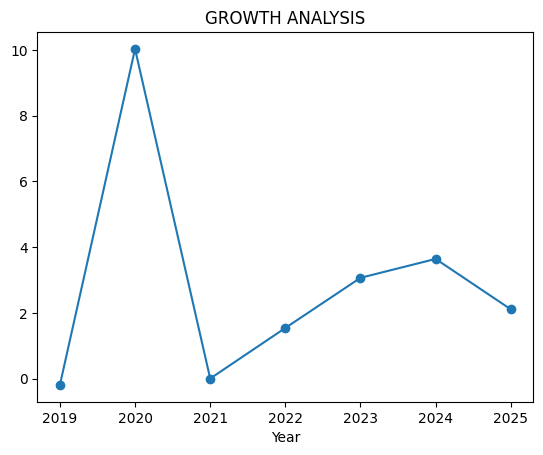

In [17]:
# Step 2: Data Visualization
growth.plot(x="year",y="growth",marker="o")
plt.title("GROWTH ANALYSIS")
plt.show()

**Insight:**

Sales growth shows fluctuations over the years. There is a strong increase of around 10% from 2019 to 2020, followed by no growth between 2020 and 2021. From 2021 onwards, growth remains moderate with slight increases, but declines are observed in later years, especially around 2023 to 2024. Overall, the growth trend is inconsistent with both positive and negative changes.

### Correlation Analysis

In [18]:
# Step 1: Data Preparation
cor_analysis=bmw_dataset[["Units_Sold","Avg_Price_EUR","GDP_Growth"]].corr()
cor_analysis



,Units_Sold,Avg_Price_EUR,GDP_Growth
Units_Sold,1.000000,0.039163,-0.015432
Avg_Price_EUR,0.039163,1.000000,-0.000511
GDP_Growth,-0.015432,-0.000511,1.000000


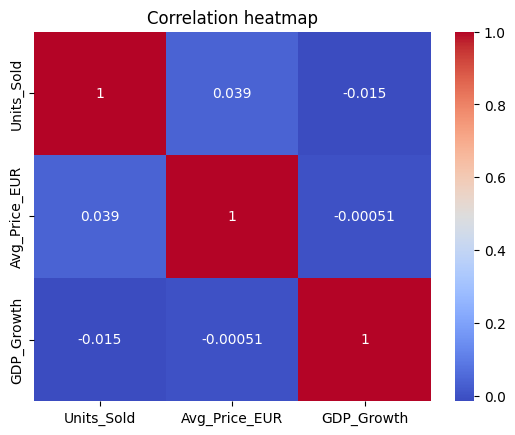

In [19]:
# Step 2: Data visualization
sns.heatmap(data=cor_analysis,annot=True,cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

**Insight:**

The heatmap shows no strong correlation between sales, price, and GDP, indicating that BMW operates in a stable luxury segment where demand is largely independent of economic and pricing fluctuations.

### Insights Selection



**1. Sales Trend:**  
Sales experienced a slight decline initially, followed by a strong recovery and consistent growth in subsequent years, indicating overall business expansion.

**2. Seasonality:**  
Sales exhibit a fluctuating seasonal pattern throughout the year, with periodic peaks and dips indicating varying monthly demand.

**3. Regional Performance:**  
Sales are relatively evenly distributed across regions, suggesting a well-balanced global market presence without heavy reliance on a single region.

**4. Region vs Model Performance:**  
X5 and X7 consistently perform well across multiple regions, while Mini and X3 show comparatively weaker performance in certain markets.

**5. Units vs Revenue:**  
Units sold remain stable, while revenue fluctuates more, indicating the impact of pricing and premium model sales.

**6. Growth Analysis:**  
Growth shows fluctuations with both positive and negative changes but maintains an overall upward trend.

**7. Correlation Analysis:**  
No strong correlation between sales, price, and GDP, indicating stable demand independent of external factors.